**Objetivo**: Agrupar perfiles de compradores según comportamiento de gasto.

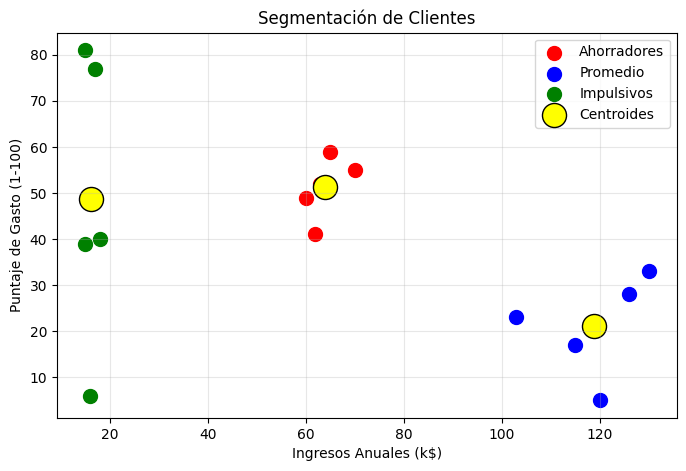

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def segmentacion_compras():
    """
    Simula la segmentacion de clientes basada en Ingresos y Gasto.
    """
    # Datos sintéticos: [Ingreso_k$, Gasto_0-100]
    data = np.array([[15, 39], [15, 81], [16, 6], [17, 77], [18, 40],
                     [60, 49], [62, 41], [63, 52], [65, 59], [70, 55],
                     [126, 28], [130, 33], [103, 23], [115, 17], [120, 5]])

    # Aplicar K-Means con K=3
    '''
    init='k-means++':  Esto especifica el método para inicializar los centroides. 'k-means++' es una forma inteligente de elegir centros de clúster iniciales que tienden a acelerar la convergencia.
    n_init=10:  Esto significa que el algoritmo se ejecutará 10 veces con diferentes semillas de centroide, y el resultado final será la mejor salida de estas 10 ejecuciones consecutivas en términos de inercia (suma de las distancias cuadradas de las muestras a su centro de clúster más cercano).
    '''
    kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
    y_predict = kmeans.fit_predict(data)

    # Visualización
    plt.figure(figsize=(8, 5))
    colors = ['red', 'blue', 'green']
    labels = ['Ahorradores', 'Promedio', 'Impulsivos']
    #labels = ['Promedio', 'Ahorradores', 'Impulsivos']

    # s=100 specifies the size of the markers (points) in the scatter plot.

    for i in range(3):
        plt.scatter(data[y_predict == i, 0], data[y_predict == i, 1],
                    s=100, c=colors[i], label=labels[i])

    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=300, c='yellow', label='Centroides', edgecolors='black')
    plt.title('Segmentación de Clientes')
    plt.xlabel('Ingresos Anuales (k$)')
    plt.ylabel('Puntaje de Gasto (1-100)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

segmentacion_compras()
